---
# **TAREA XOR A MANO(sin librerias)**
---



---

| **Universitario** | Vismark Abner Choque Cachi |
|------------------|---------------------------|
| **Materia**      | Deep Learning         |
| **Docente**      | Ph.D. Moises Martin Silva Choque|
| **Sigla**        | DAT-264                   |
---
---


In [53]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [54]:
# CADA NEURONA REPRESENTA UN HIPERPLANO
inputs = np.array([
    [0, 0, 1],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
])
y = np.array([[0],[1],[1],[0]])


In [55]:
class RedNeuronalXOR:
    def __init__(self, tamano_entrada, tamano_oculta, tamano_salida):
        self.tamano_entrada = tamano_entrada
        self.tamano_oculta = tamano_oculta
        self.tamano_salida = tamano_salida

        # Pesos aleatorios
        self.W1 = np.random.normal(scale=0.5, size=(tamano_entrada, tamano_oculta))
        self.W2 = np.random.normal(scale=0.5, size=(tamano_oculta, tamano_salida))

        # Bias
        self.b1 = np.random.normal(scale=0.5, size=(1, tamano_oculta))
        self.b2 = np.random.normal(scale=0.5, size=(1, tamano_salida))

    # Funcion de activacion Sigmoid
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def d_sigmoid(self, x):
        return x * (1 - x)

    # Propagacion hacia adelante
    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.salida = self.sigmoid(self.z2)
        return self.salida

    # Calculo de error (MSE)
    def error(self, salida, y):
        return np.mean((salida - y) ** 2) / 2

    # Backpropagation
    def backward(self, X, y, lr):
        salida = self.forward(X)
        delta_salida = (salida - y) * self.d_sigmoid(salida)
        d_W2 = np.dot(self.a1.T, delta_salida)
        d_b2 = np.sum(delta_salida, axis=0, keepdims=True)

        delta_oculta = np.dot(delta_salida, self.W2.T) * self.d_sigmoid(self.a1)
        d_W1 = np.dot(X.T, delta_oculta)
        d_b1 = np.sum(delta_oculta, axis=0, keepdims=True)

        # Actualizar pesos y bias
        self.W2 -= lr * d_W2
        self.b2 -= lr * d_b2
        self.W1 -= lr * d_W1
        self.b1 -= lr * d_b1

        return self.error(salida, y)


derivada de la sigmoide  es (sigmoide(z))' = (sigmoide(z))'*(1-sigmoide(z))   
1/2 (output' - y) **2  
1/2 (sigmoid(z2) -y) **2  
1/2 ((sigmoid(a1*W2))-y)**2        
1/2 ((sigmoid(sigmoid(z1)*W2))-y)**2  
1/2 ((sigmoid(sigmoid(X*W1)*W2))-y)**2  
BACKPROPAGATION  
(1/2 (y' - y) **2)'  //  (output-y)    
sigmoid(output)'         //  output(1-output)  
(a1*W2 + b2)'        //  a1    respecto a **w2**    a1*output(1-output)*(output-y)
                                                    a1 * sigmoid(output) *(output-y)
                         //   1    respecto a **b2**    output(1-output)*(output-y)  
(sigmoid(z1)*w2)'       //  a1(1-a1) * w2  
X*W1 + b1            //  X     respecto a **w1**  
                            x.t*sigmoid'(a1)*W2*sigmoid'(z2)*(output-y)
   
                     //  1     respecto a **b1**    1*a1(1-a1)*a1*output(1-output)*...(output-y)
                    



In [56]:
nnn = RedNeuronalXOR(3,3,1)
print('antes PRIMERA ITERACION')
print(nnn.forward(inputs))
print('luego')
errores = []
error = 1
n = 0
while error > 0.001:
    error = nnn.backward(inputs,y,0.2)
    errores.append(error)
    n+=1
print('numero de iteraciones o epocas',n)
print(nnn.forward(inputs))

antes PRIMERA ITERACION
[[0.42437299]
 [0.45380712]
 [0.38161343]
 [0.40907224]]
luego
numero de iteraciones o epocas 6969
[[0.01880421]
 [0.95476049]
 [0.9520634 ]
 [0.05743255]]


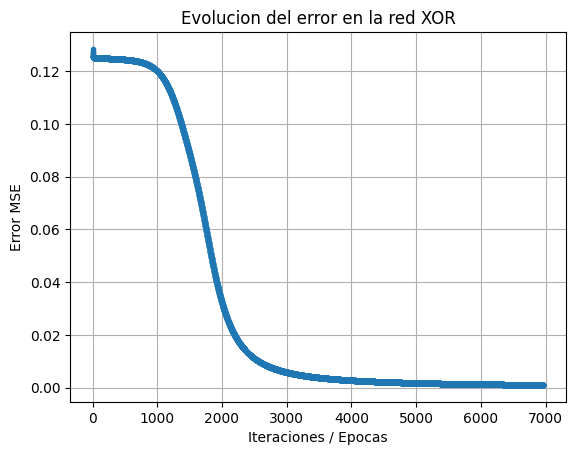

In [57]:
import matplotlib.pyplot as plt

plt.plot(range(len(errores)), errores, marker='o', markersize=3, linewidth=0.8) 
plt.title("Evolucion del error en la red XOR")
plt.xlabel("Iteraciones / Epocas")
plt.ylabel("Error MSE")
plt.grid(True)
plt.show()


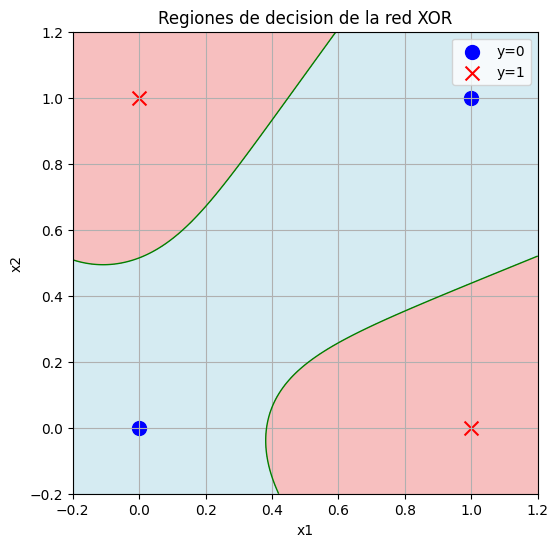

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Crear malla de puntos en el plano
resolucion = 200
xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, resolucion),
                     np.linspace(-0.2, 1.2, resolucion))

# Aplanar la malla y agregar columna de 1 para bias
grid = np.c_[xx.ravel(), yy.ravel(), np.ones(xx.size)]

# Salida de la red para cada punto
zz = nnn.forward(grid)
zz = zz.reshape(xx.shape)

# Graficar regiones con colores
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, zz, levels=[0,0.5,1], colors=['lightblue','lightcoral'], alpha=0.5)

# Dibujar linea de frontera donde salida = 0.5
plt.contour(xx, yy, zz, levels=[0.5], colors='green', linewidths=1)

# Dibujar puntos de entrenamiento
plt.scatter(inputs[y.flatten()==0][:,0], inputs[y.flatten()==0][:,1], 
            color='blue', marker='o', s=100, label='y=0')
plt.scatter(inputs[y.flatten()==1][:,0], inputs[y.flatten()==1][:,1], 
            color='red', marker='x', s=100, label='y=1')

plt.title('Regiones de decision de la red XOR')
plt.xlabel('x1')
plt.ylabel('x2')
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.legend()
plt.grid(True)
plt.show()
